# Netflix movies and tv shows Analysis Notebook

### Importing important libraries

In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [244]:
# Loading Data using pandas from netflix_titles.csv file

url = "netflix_titles.csv"
df = pd.read_csv(url)
df.head()
all_fig = []

## Data inspecting

In [245]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [247]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [248]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [249]:
df.duplicated().sum()

np.int64(0)

## Data cleaning and formating

In [250]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [251]:
# df[["director", "cast", "country", "rating", "duration"]] = df[["director", "cast", "country", "rating", "duration"]].fillna("Unknown")

In [252]:
# df["date_added"] = df["date_added"].fillna()

In [253]:
df["date_added"] = pd.to_datetime(df["date_added"], format="mixed")
df["date_added"]

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]

In [254]:
import datetime as dt

df["Year_added"] = df["date_added"].dt.year
df.sample()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_added
2054,s2055,TV Show,Chef's Table: BBQ,NaN,NaN,United States,2020-09-02,2020,TV-14,1 Season,"Docuseries, Reality TV",The Emmy-nominated series delves into the juic...,2020.0


In [255]:
# df = df.drop_duplicates().dropna()

## Data wrangling and visulalization

## Content Type Distribution

In [256]:
# Count of Different type of content
count_type = df.type.value_counts().reset_index()
count_type

,type,count
0,Movie,6131
1,TV Show,2676


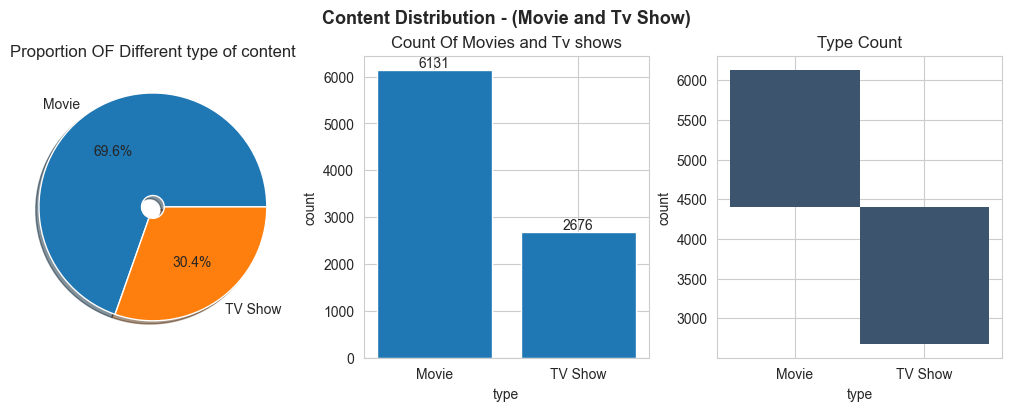

In [257]:
fig, ax = plt.subplots(ncols =3,figsize=(10, 4), layout="constrained")

ax[0].pie(count_type["count"], labels= count_type["type"], autopct = "%1.1f%%", labeldistance = 1.1, shadow= True, wedgeprops=dict(width=0.9))
ax[0].set(title ="Proportion OF Different type of content")

# plt.pie()
a1 = ax[1].bar(count_type["type"], count_type["count"])
ax[1].bar_label(a1, count_type["count"])
ax[1].set(title = "Count Of Movies and Tv shows", xlabel = "type", ylabel = "count")

sns.histplot(x = count_type["type"], y = count_type["count"])
ax[2].set(title = "Type Count")

fig.suptitle('Content Distribution - (Movie and Tv Show)', fontsize = 13, fontweight = "bold")
# plt.savefig("Untitled Folder 1/figure.png", dpi = 100, bbox_inches='tight')
all_fig.append(fig)
plt.show()

## Temporal analyis of netflix

### Distribution by Release year

In [258]:
# Distribution of type of content on netflix as per the movie release year
movie_per_year = df.groupby(["release_year", "type"])["title"].count().unstack().fillna(0)
# movie_per_year = df.groupby(["release_year", "type"])["title"].count().reset_index()
movie_per_year["total"] = movie_per_year["Movie"] + movie_per_year["TV Show"]
movie_per_year

type,Movie,TV Show,total
release_year,,,
1925,0.0,1.0,1.0
1942,2.0,0.0,2.0
1943,3.0,0.0,3.0
1944,3.0,0.0,3.0
1945,3.0,1.0,4.0
...,...,...,...
2017,767.0,265.0,1032.0
2018,767.0,380.0,1147.0
2019,633.0,397.0,1030.0


#### Distribution by Release year (Last 10 year)

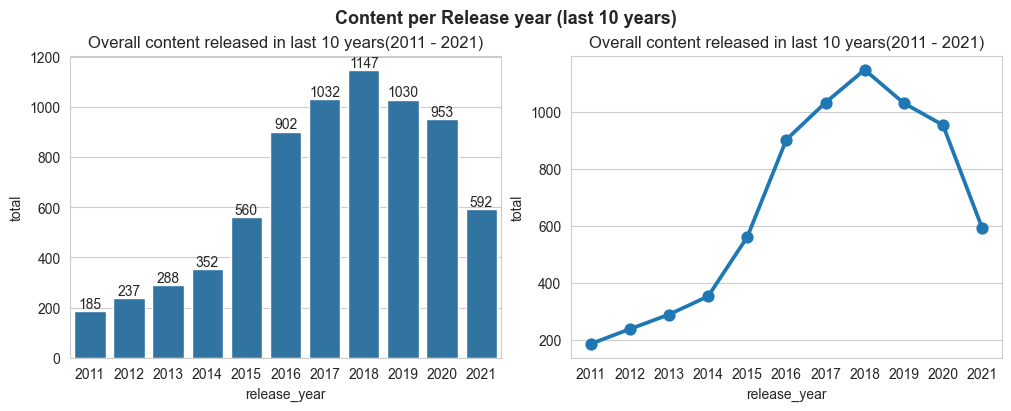

In [259]:
fig, ax = plt.subplots(ncols= 2, figsize = (10, 4), layout = "constrained")

year_10 = df["release_year"].max() - 10
data1 = movie_per_year.loc[year_10:]

sns.barplot(ax = ax[0], data = data1, x = "release_year", y = "total")
ax[0].bar_label(ax[0].containers[0])
ax[0].set(title = f"Overall content released in last 10 years({year_10} - {df["release_year"].max()})")

sns.pointplot(ax = ax[1], data = data1, x = "release_year", y = "total")
ax[1].set(title = f"Overall content released in last 10 years({year_10} - {df["release_year"].max()})")

fig.suptitle('Content per Release year (last 10 years)', fontsize = 13, fontweight = "bold")
all_fig.append(fig)
plt.show()

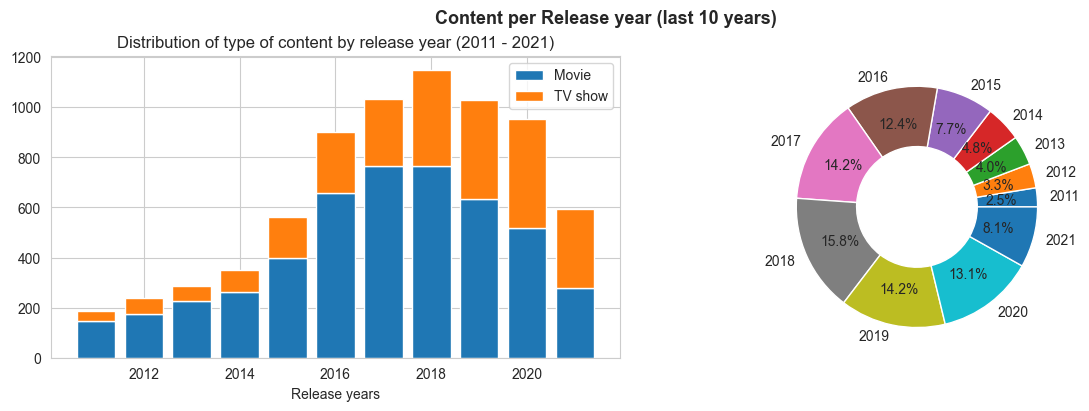

In [260]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 4), layout = "constrained")
ax[0].bar(data1.index, data1["Movie"], label = "Movie")
ax[0].bar(data1.index, data1["TV Show"], bottom=data1["Movie"], label = "TV show")
ax[0].legend()
ax[0].set_xlabel("Release years")
# plt.bar_label()
ax[0].set(title = f"Distribution of type of content by release year ({year_10} - {df["release_year"].max()})")

ax[1].pie(data1["total"], labels=data1.index, wedgeprops=dict(width = 0.5), autopct = "%0.1f%%", labeldistance= 1.1, pctdistance= 0.7)

fig.suptitle('Content per Release year (last 10 years)', fontsize = 13, fontweight = "bold")
all_fig.append(fig)
plt.show()

In [261]:
data1

type,Movie,TV Show,total
release_year,,,
2011,145.0,40.0,185.0
2012,173.0,64.0,237.0
2013,225.0,63.0,288.0
2014,264.0,88.0,352.0
2015,398.0,162.0,560.0
2016,658.0,244.0,902.0
2017,767.0,265.0,1032.0
2018,767.0,380.0,1147.0
2019,633.0,397.0,1030.0


In [262]:
release = df.groupby(["release_year", "type"])["title"].count().reset_index()
release = release.rename(columns = {"title": "count"})
release_after = release[release["release_year"] >= year_10]
release_after

,release_year,type,count
97,2011,Movie,145
98,2011,TV Show,40
99,2012,Movie,173
100,2012,TV Show,64
101,2013,Movie,225
102,2013,TV Show,63
103,2014,Movie,264
104,2014,TV Show,88
105,2015,Movie,398
106,2015,TV Show,162


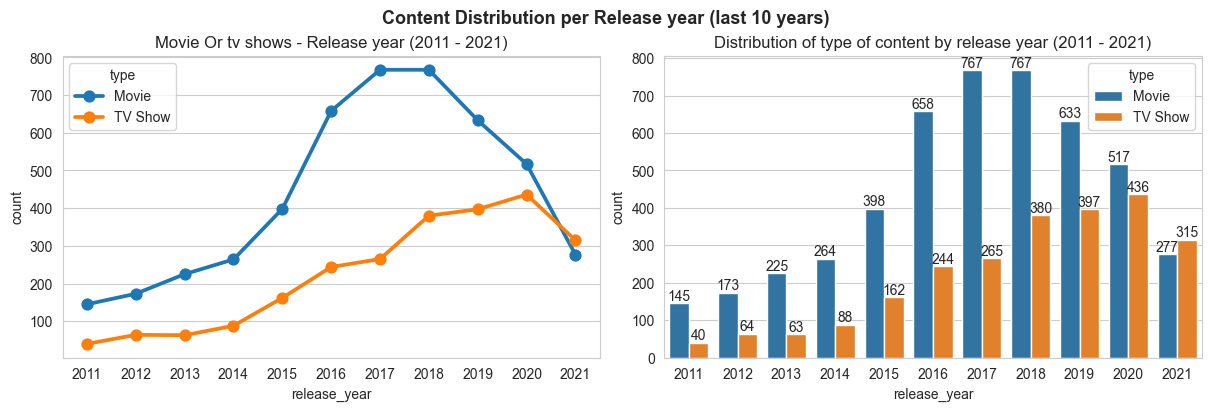

In [263]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 4), layout = "constrained")

sns.pointplot(ax = ax[0], data = release_after, x = "release_year", y = "count", hue="type")
ax[0].set(title = f"Movie Or tv shows - Release year ({year_10} - {df["release_year"].max()})")

sns.barplot(ax = ax[1], data = release_after, y = "count", x = "release_year", hue="type")
ax[1].bar_label(ax[1].containers[0])
ax[1].bar_label(ax[1].containers[1])
ax[1].set(title = f"Distribution of type of content by release year ({year_10} - {df["release_year"].max()})")
# for i in ax.mouseover():
#     print(i)

fig.suptitle('Content Distribution per Release year (last 10 years)', fontsize = 13, fontweight = "bold")
all_fig.append(fig)
plt.show()

### Distribution by Content added (year and month wise)

In [264]:
df["date_added"].dt.year # Date Added By Year

0       2021.0
1       2021.0
2       2021.0
3       2021.0
4       2021.0
         ...  
8802    2019.0
8803    2019.0
8804    2019.0
8805    2020.0
8806    2019.0
Name: date_added, Length: 8807, dtype: float64

In [265]:
groByYear = df.groupby([df["date_added"].dt.year, "type"]).size().unstack(fill_value=0)
groByYear['total'] = groByYear["Movie"] + groByYear["TV Show"]
groByYear

type,Movie,TV Show,total
date_added,,,
2008.0,1,1,2
2009.0,2,0,2
2010.0,1,0,1
2011.0,13,0,13
2012.0,3,0,3
2013.0,6,5,11
2014.0,19,5,24
2015.0,56,26,82
2016.0,253,176,429


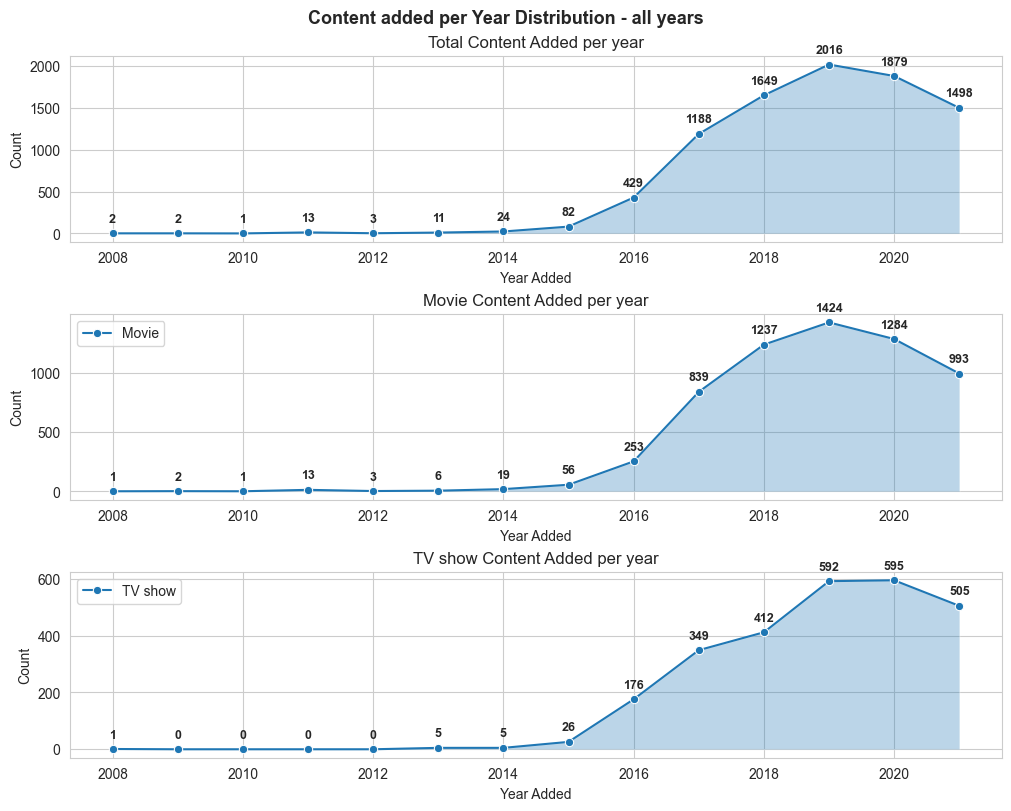

In [266]:
fig, ax = plt.subplots(nrows = 3, figsize = (10, 8), layout = "constrained")

sns.lineplot(ax = ax[0], data= groByYear, x = groByYear.index, y  = "total", marker= "o")
ax[0].fill_between(x = groByYear.index, y1 = groByYear["total"], alpha=0.3)
for x, y in zip(groByYear.index, groByYear.total):
    ax[0].annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=9, fontweight='bold')
ax[0].set(title = "Total Content Added per year", xlabel = "Year Added", ylabel = "Count")

sns.lineplot(ax = ax[1], data= groByYear, x = groByYear.index, y = "Movie", marker= "o", label = "Movie")
ax[1].fill_between(x = groByYear.index, y1 = groByYear["Movie"], alpha=0.3)
for x, y in zip(groByYear.index, groByYear.Movie):
    ax[1].annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=9, fontweight='bold')
ax[1].set(title = "Movie Content Added per year", xlabel = "Year Added", ylabel = "Count")                        

sns.lineplot(ax = ax[2], data = groByYear, x = groByYear.index, y = "TV Show", marker= "o", label = "TV show")
ax[2].fill_between(x = groByYear.index, y1 = groByYear["TV Show"], alpha=0.3)
for x, y in zip(groByYear.index, groByYear["TV Show"]):
    ax[2].annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=9, fontweight='bold')
ax[2].set(title = "TV show Content Added per year", xlabel = "Year Added", ylabel = "Count")

fig.suptitle('Content added per Year Distribution - all years', fontsize = 13, fontweight = "bold")
# fig.tight_layout()
all_fig.append(fig)
plt.show()

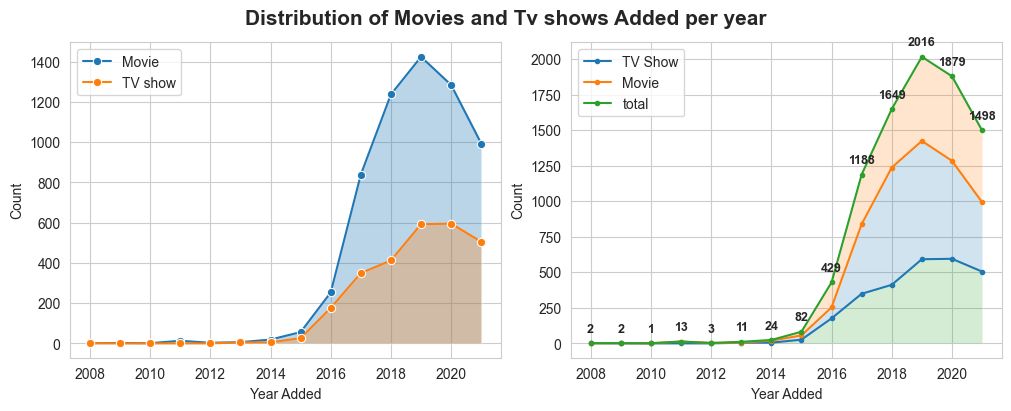

In [267]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 4), layout = "constrained")


sns.lineplot(ax = ax[0], data = groByYear, x = groByYear.index, y = "Movie", marker= "o", label = "Movie")
ax[0].fill_between(x = groByYear.index, y1 = groByYear["Movie"], alpha=0.3)
# for x, y in zip(groByYear.index, groByYear.Movie):
#     plt.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8),
#                      ha='center', fontsize=9, fontweight='bold')

sns.lineplot(ax = ax[0], data = groByYear, x = groByYear.index, y = "TV Show", marker= "o", label = "TV show")
ax[0].fill_between(x = groByYear.index, y1 = groByYear["TV Show"], alpha=0.3)
# for x, y in zip(groByYear.index, groByYear["TV Show"]):
#     plt.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8),
#                      ha='center', fontsize=9, fontweight='bold')
ax[0].legend()
ax[0].set(xlabel = "Year Added", ylabel = "Count")

ax[1].plot(groByYear.index, groByYear["TV Show"], marker = "o", markersize = 3, label = "TV Show")
ax[1].plot(groByYear.index, groByYear["Movie"], marker = "o", markersize = 3, label = "Movie")
ax[1].plot(groByYear.index, groByYear["total"], marker = "o", markersize = 3, label = "total")
ax[1].fill_between(groByYear.index, groByYear["Movie"], groByYear["TV Show"], alpha = 0.2)
ax[1].fill_between(groByYear.index, groByYear["total"], groByYear["Movie"], alpha = 0.2)
ax[1].fill_between(groByYear.index, groByYear["TV Show"], alpha = 0.2)
for x, y in zip(groByYear.index, groByYear.total):
    ax[1].annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=9, fontweight='bold')
ax[1].set(xlabel = "Year Added", ylabel = "Count")
ax[1].legend()

fig.suptitle("Distribution of Movies and Tv shows Added per year", fontsize = 15, fontweight = "bold")
all_fig.append(fig)
plt.show()


In [268]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
addByMonth = df.groupby([df["date_added"].dt.strftime("%B"), "type"]).size().unstack(fill_value=0).reindex(month_order)
addByMonth['total'] = addByMonth["Movie"] + addByMonth["TV Show"]
addByMonth

type,Movie,TV Show,total
date_added,,,
January,546,192,738
February,382,181,563
March,529,213,742
April,550,214,764
May,439,193,632
June,492,236,728
July,565,262,827
August,519,236,755
September,519,251,770


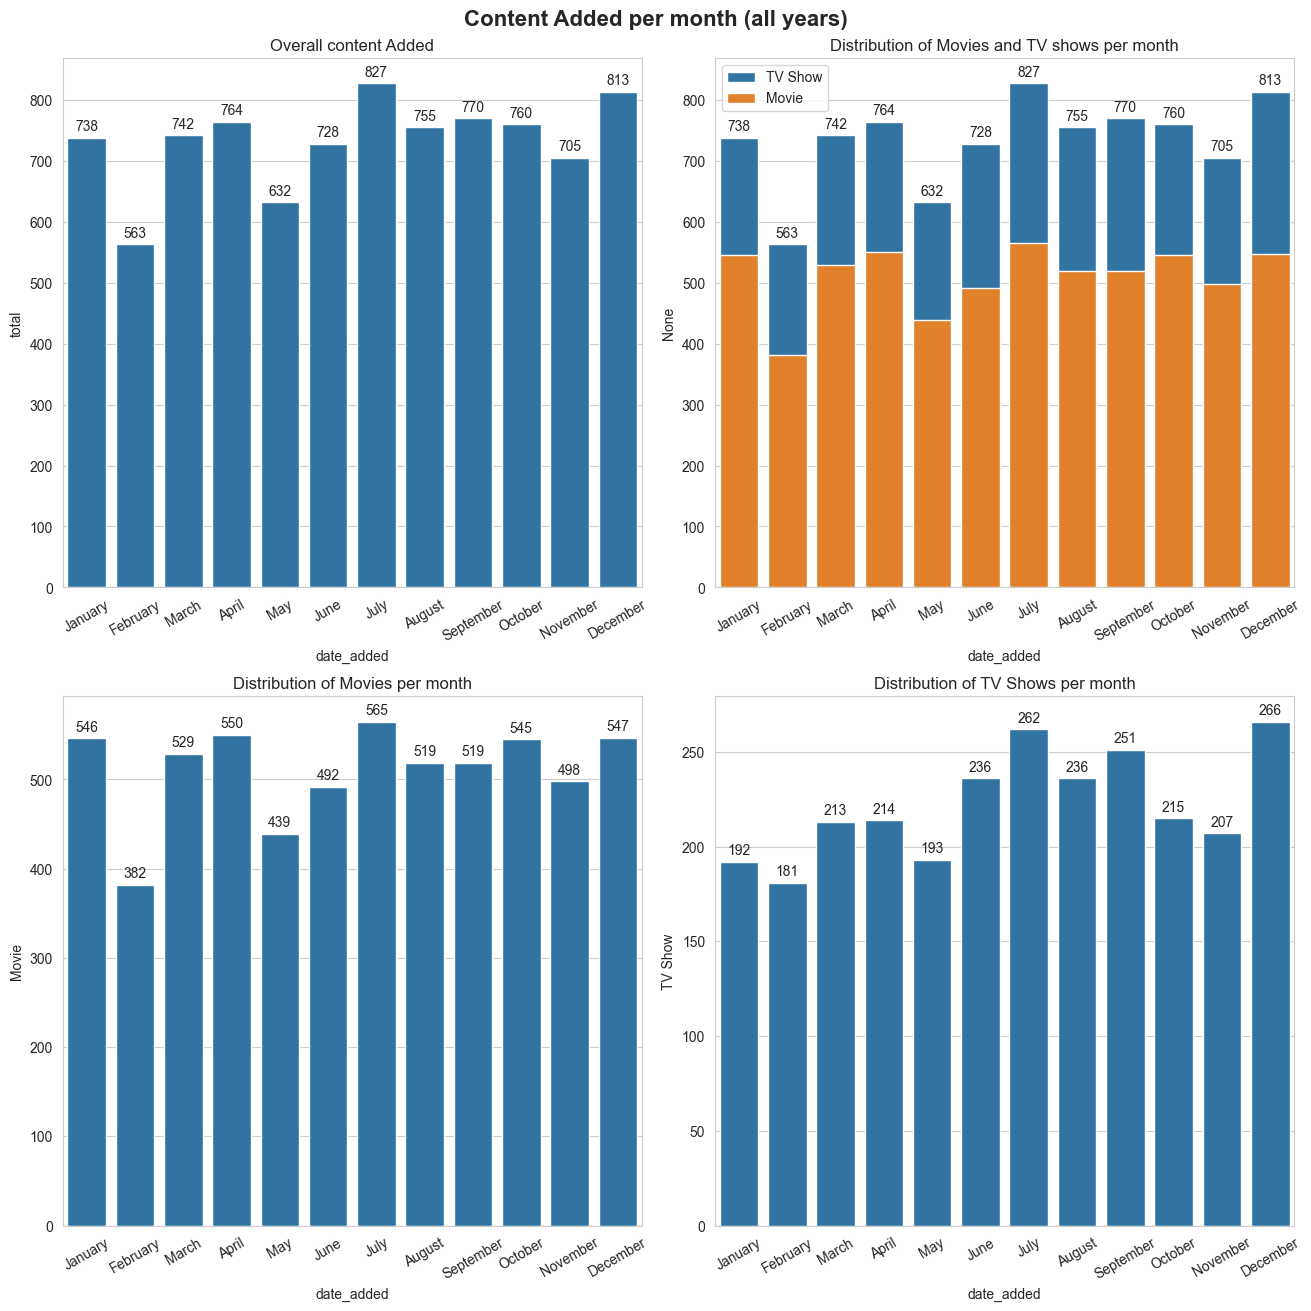

In [269]:
fig, ax = plt.subplots(ncols = 2, nrows= 2, figsize= (13, 13), layout = "constrained")

sns.barplot(ax = ax[0, 0], data = addByMonth, x = addByMonth.index, y = addByMonth["total"])
ax[0, 0].tick_params(axis = 'x', rotation = 30)
ax[0, 0].bar_label(ax[0, 0].containers[0], padding=3)
ax[0, 0].set_title("Overall content Added")


sns.barplot(ax = ax[0, 1],data = addByMonth, x = addByMonth.index, y = addByMonth["TV Show"] + addByMonth["Movie"], label = "TV Show")
sns.barplot(ax = ax[0, 1], data = addByMonth, x = addByMonth.index, y = addByMonth["Movie"], label = "Movie")
ax[0, 1].tick_params(axis = 'x', rotation = 30)
ax[0, 1].set(yscale  = "linear")
ax[0, 1].bar_label(ax[0,1].containers[0], padding=3)
ax[0, 1].set_title("Distribution of Movies and TV shows per month")

sns.barplot(ax = ax[1, 0], data = addByMonth, x = addByMonth.index, y = addByMonth["Movie"])
ax[1, 0].tick_params(axis = 'x', rotation = 30)
# ax[0,1].set(yscale  = "linear")
ax[1, 0].bar_label(ax[1, 0].containers[0], padding=3)
ax[1, 0].set_title("Distribution of Movies per month")

sns.barplot(ax = ax[1, 1], data = addByMonth, x = addByMonth.index, y = addByMonth["TV Show"])
ax[1, 1].tick_params(axis = 'x', rotation = 30)
# ax[0,1].set(yscale  = "linear")
ax[1, 1].bar_label(ax[1, 1].containers[0], padding=3)
ax[1, 1].set_title("Distribution of TV Shows per month")

fig.suptitle("Content Added per month (all years)", fontsize=16, fontweight='bold')
all_fig.append(fig)
plt.show()

In [270]:
df["release_year"].min()

1925

In [271]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


In [272]:
differece_dateRe_Ad = df["date_added"].dt.year - df["release_year"]
differece_dateRe_Ad.median()

1.0

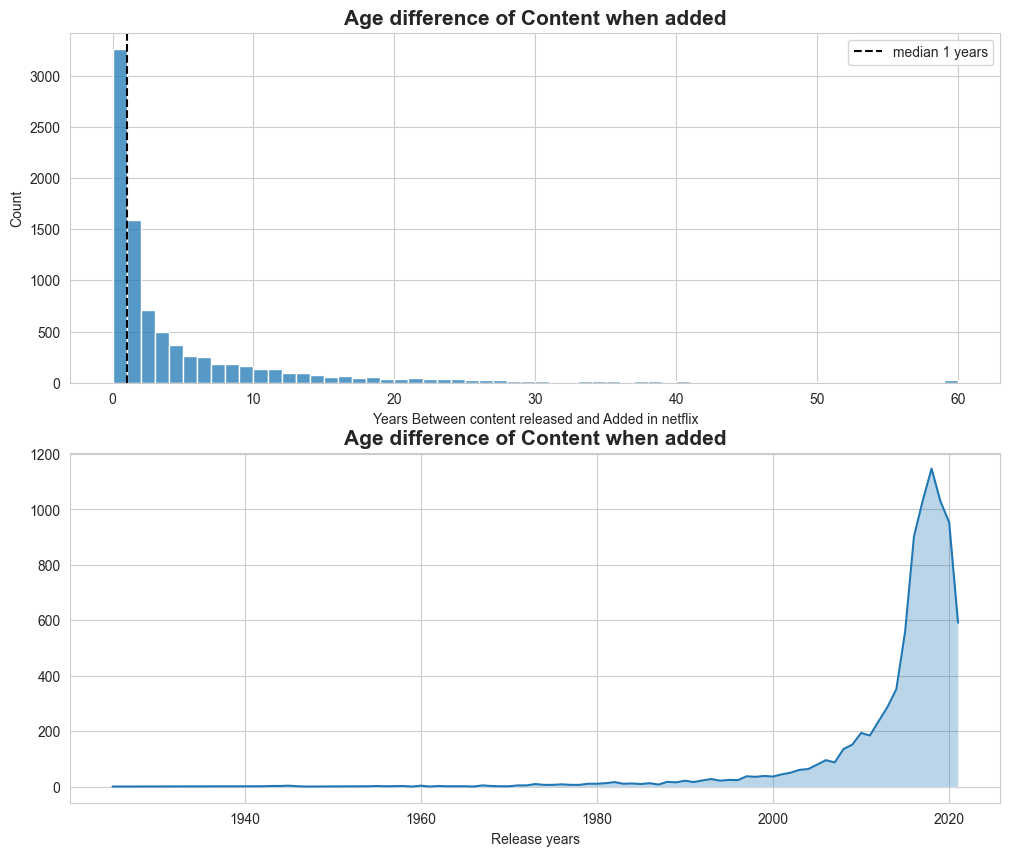

In [273]:
fig, ax = plt.subplots(nrows = 2, figsize = (12,10))

sns.histplot(ax = ax[0], x = differece_dateRe_Ad.clip(0, 60), bins = 60)
ax[0].axvline(differece_dateRe_Ad.median(), color = "black", linestyle = "--", label = f"median {differece_dateRe_Ad.median():.0f} years")
ax[0].legend()
ax[0].set_xlabel("Years Between content released and Added in netflix")
ax[0].set_title("Age difference of Content when added", fontsize = 15, fontweight = "bold")

ax[1].plot(movie_per_year.index, movie_per_year["total"])
ax[1].fill_between(x = movie_per_year.index, y1 = movie_per_year["total"], alpha = 0.3)
ax[1].set_title("Age difference of Content when added", fontsize = 15, fontweight = "bold")
ax[1].set_xlabel("Release years")
all_fig.append(fig)
plt.show()

### Director Analysis

In [274]:
df["director"].isna().sum()

np.int64(2634)

In [275]:
director = df["director"].dropna().str.split(", ").explode().value_counts().reset_index().head(10)
print(director)
# print(director["count"].head(20).sum())

              director  count
0        Rajiv Chilaka     22
1            Jan Suter     21
2          Raúl Campos     19
3          Suhas Kadav     16
4         Marcus Raboy     16
5            Jay Karas     15
6  Cathy Garcia-Molina     13
7          Jay Chapman     12
8      Youssef Chahine     12
9      Martin Scorsese     12


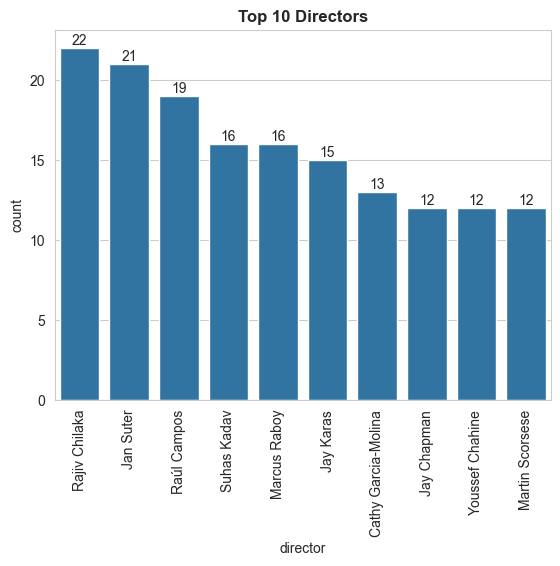

In [276]:
ax = sns.barplot(data = director, x = "director", y = "count")
plt.xticks(rotation = 90)
plt.bar_label(ax.containers[0])
plt.title("Top 10 Directors", fontweight = "bold")
all_fig.append(plt.gcf())
plt.show()

### Rating Analysis

In [277]:
rating_mapping = {
    'TV-Y': "Children",
    'TV-Y7': "Children",
    'TV-Y7-FV': "Children",
    'TV-G': "Family",
    'G': "Family",
    'TV-PG': "Teen",
    'PG': "Teen",
    'PG-13': "Teen",
    'TV-14': "Teen",
    'R': "Adult",
    'TV-MA':"Adult",
    'NC-17': "Adult",
    'TV-Y': "Children",
    'NR':"Not rated",
    "UR": "Un rated"
}

df["Rate_category"] = df["rating"].map(rating_mapping)

In [278]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_added,Rate_category
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,Teen
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,Adult
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,Adult
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,Adult
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,Adult


In [279]:
valid_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17','TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G', 'TV-PG', 'TV-14', 'TV-MA', 'UR', 'NR', 'Unknown']
df_ratings = df[df['rating'].isin(valid_ratings)]
ratings_order = ["TV-Y", "TV-Y7", 'TV-Y7-FV', "TV-G", "G", "PG", "TV-PG", "PG-13", "TV-14", "TV-MA", "R", "NC-17", "NR", "UR"]
rating = df_ratings.groupby(["type", "rating", "Rate_category"])["title"].count().unstack(level = 0).fillna(0).reindex(ratings_order, level=0).reset_index()
rating["total"] = rating["Movie"] + rating["TV Show"]
rating

type,rating,Rate_category,Movie,TV Show,total
0,TV-Y,Children,131.0,176.0,307.0
1,TV-Y7,Children,139.0,195.0,334.0
2,TV-Y7-FV,Children,5.0,1.0,6.0
3,TV-G,Family,126.0,94.0,220.0
4,G,Family,41.0,0.0,41.0
5,PG,Teen,287.0,0.0,287.0
6,TV-PG,Teen,540.0,323.0,863.0
7,PG-13,Teen,490.0,0.0,490.0
8,TV-14,Teen,1427.0,733.0,2160.0
9,TV-MA,Adult,2062.0,1145.0,3207.0


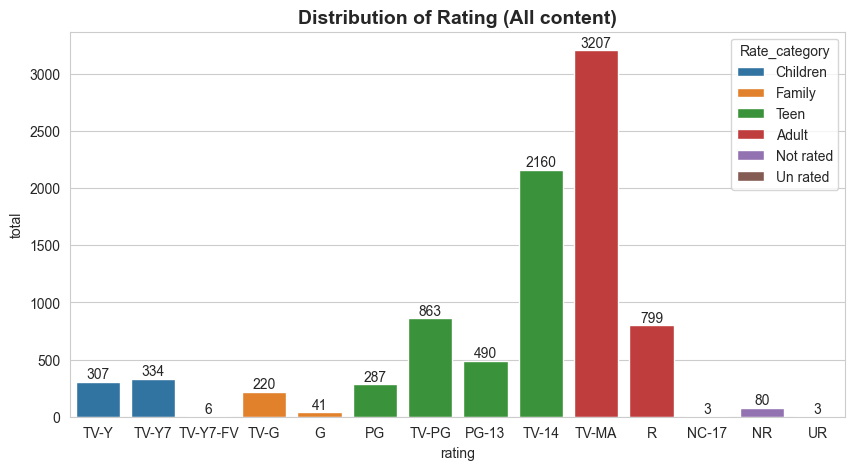

In [280]:
plt.figure(figsize = (10, 5))
ax = sns.barplot(rating, x = "rating", y = "total", hue="Rate_category")
for i in ax.containers:
    ax.bar_label(i)
# ax.bar_label(ax.containers[1])
plt.title("Distribution of Rating (All content)", fontsize = 14, fontweight = "bold")
all_fig.append(plt.gcf())
plt.show()

In [281]:
import plotly.express as px
from plotly.subplots import make_subplots

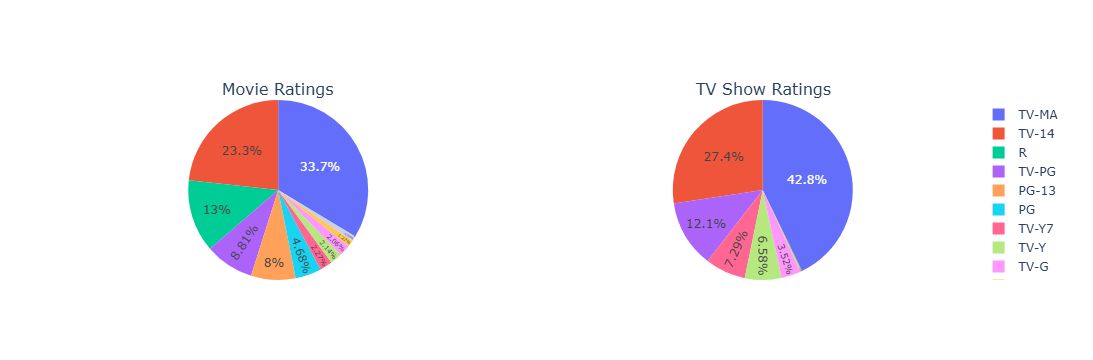

In [282]:
# px.fig()
fig = make_subplots(rows=1, cols=2, specs=[[{"type":"domain"}, {"type":"domain"}]], subplot_titles=("Movie Ratings", "TV Show Ratings"))
fig1 = px.pie(rating, "rating", "Movie", labels= True, width=800, height=500, title= "Movie Ratings")
fig1.update_traces(textposition='inside')
fig1.update_layout(uniformtext_minsize=12, uniformtext_mode='hide')

fig2 = px.pie(rating, "rating", "TV Show", labels= True, width=800, height=500, title= "TV show Ratings")
fig2.update_traces(textposition='inside')
fig2.update_layout(uniformtext_minsize=12, uniformtext_mode='hide')
# fig.show()


fig.add_trace(fig1.data[0], row=1, col=1)
fig.add_trace(fig2.data[0], row=1, col=2)


# fig2.show()

fig.write_image("Untitled Folder 1/Ratings.png", scale=2)
fig.write_html("Untitled Folder 1/Ratings.html")
fig.show()
# fig.show()

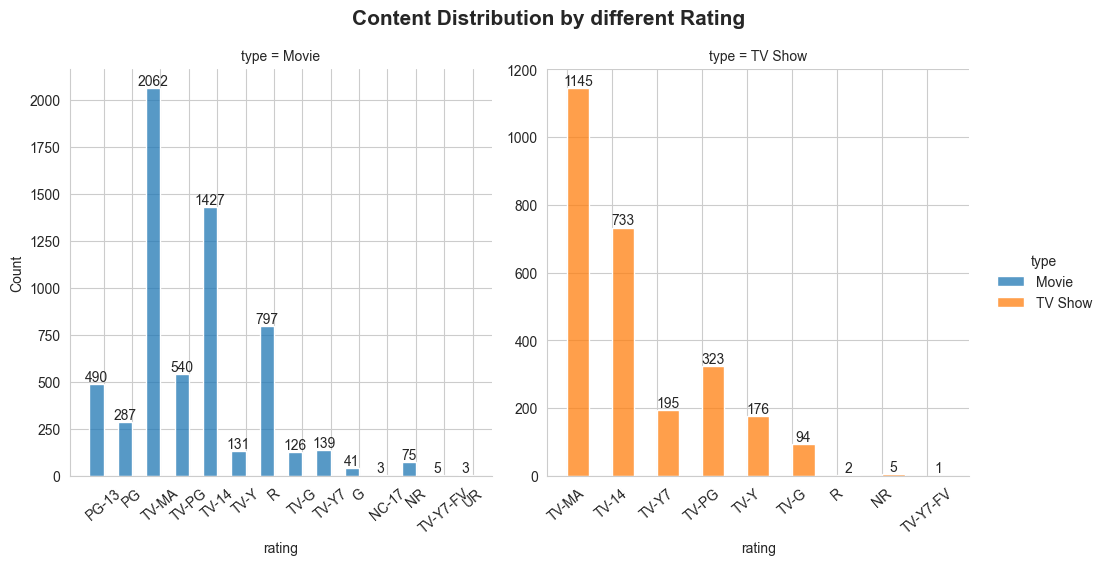

In [283]:
ax = sns.displot(data = df_ratings, x = "rating", hue = "type", kind= 'hist', col= "type", bins=10, binwidth=2, multiple="dodge", common_bins= False, facet_kws= {"sharex" : False, "sharey" : False})
for i in ax.axes.flat:
    i.tick_params(axis = 'x', rotation = 40)
    i.bar_label(i.containers[0])

ax.fig.suptitle("Content Distribution by different Rating", y=1.05, fontsize = 15, fontweight = "bold")
all_fig.append(plt.gcf())
plt.show()

### Country Wise Analysis

In [284]:
country = df["country"].str.split(", ").explode()
country = country.drop(country[country == ""].index).reset_index()
country

,index,country
0,0,United States
1,1,South Africa
2,2,NaN
3,3,NaN
4,4,India
...,...,...
10835,8802,United States
10836,8803,NaN
10837,8804,United States
10838,8805,United States


In [285]:
a = df[["type", "title"]]
a

,type,title
0,Movie,Dick Johnson Is Dead
1,TV Show,Blood & Water
2,TV Show,Ganglands
3,TV Show,Jailbirds New Orleans
4,TV Show,Kota Factory
...,...,...
8802,Movie,Zodiac
8803,TV Show,Zombie Dumb
8804,Movie,Zombieland
8805,Movie,Zoom


In [286]:
merge = pd.merge(country, a,
how = "outer",
left_on=country["index"],
right_index = True).drop(columns= "key_0")
# merge.sort_values(by="country")

merge

,index,country,type,title
0.0,0.0,United States,Movie,Dick Johnson Is Dead
1.0,1.0,South Africa,TV Show,Blood & Water
2.0,2.0,NaN,TV Show,Ganglands
3.0,3.0,NaN,TV Show,Jailbirds New Orleans
4.0,4.0,India,TV Show,Kota Factory
...,...,...,...,...
10835.0,8802.0,United States,Movie,Zodiac
10836.0,8803.0,NaN,TV Show,Zombie Dumb
10837.0,8804.0,United States,Movie,Zombieland
10838.0,8805.0,United States,Movie,Zoom


In [287]:
grou = merge.groupby(["country", "type"])["title"].count().unstack().fillna(0)
grou["total"] = grou["Movie"] + grou["TV Show"]
da_countryTop15 = grou.sort_values(by="total", ascending=False).head(15)
da_countryTop15

type,Movie,TV Show,total
country,,,
United States,2751.0,938.0,3689.0
India,962.0,84.0,1046.0
United Kingdom,532.0,272.0,804.0
Canada,319.0,126.0,445.0
France,302.0,90.0,392.0
Japan,119.0,199.0,318.0
Spain,171.0,61.0,232.0
South Korea,61.0,169.0,230.0
Germany,182.0,44.0,226.0


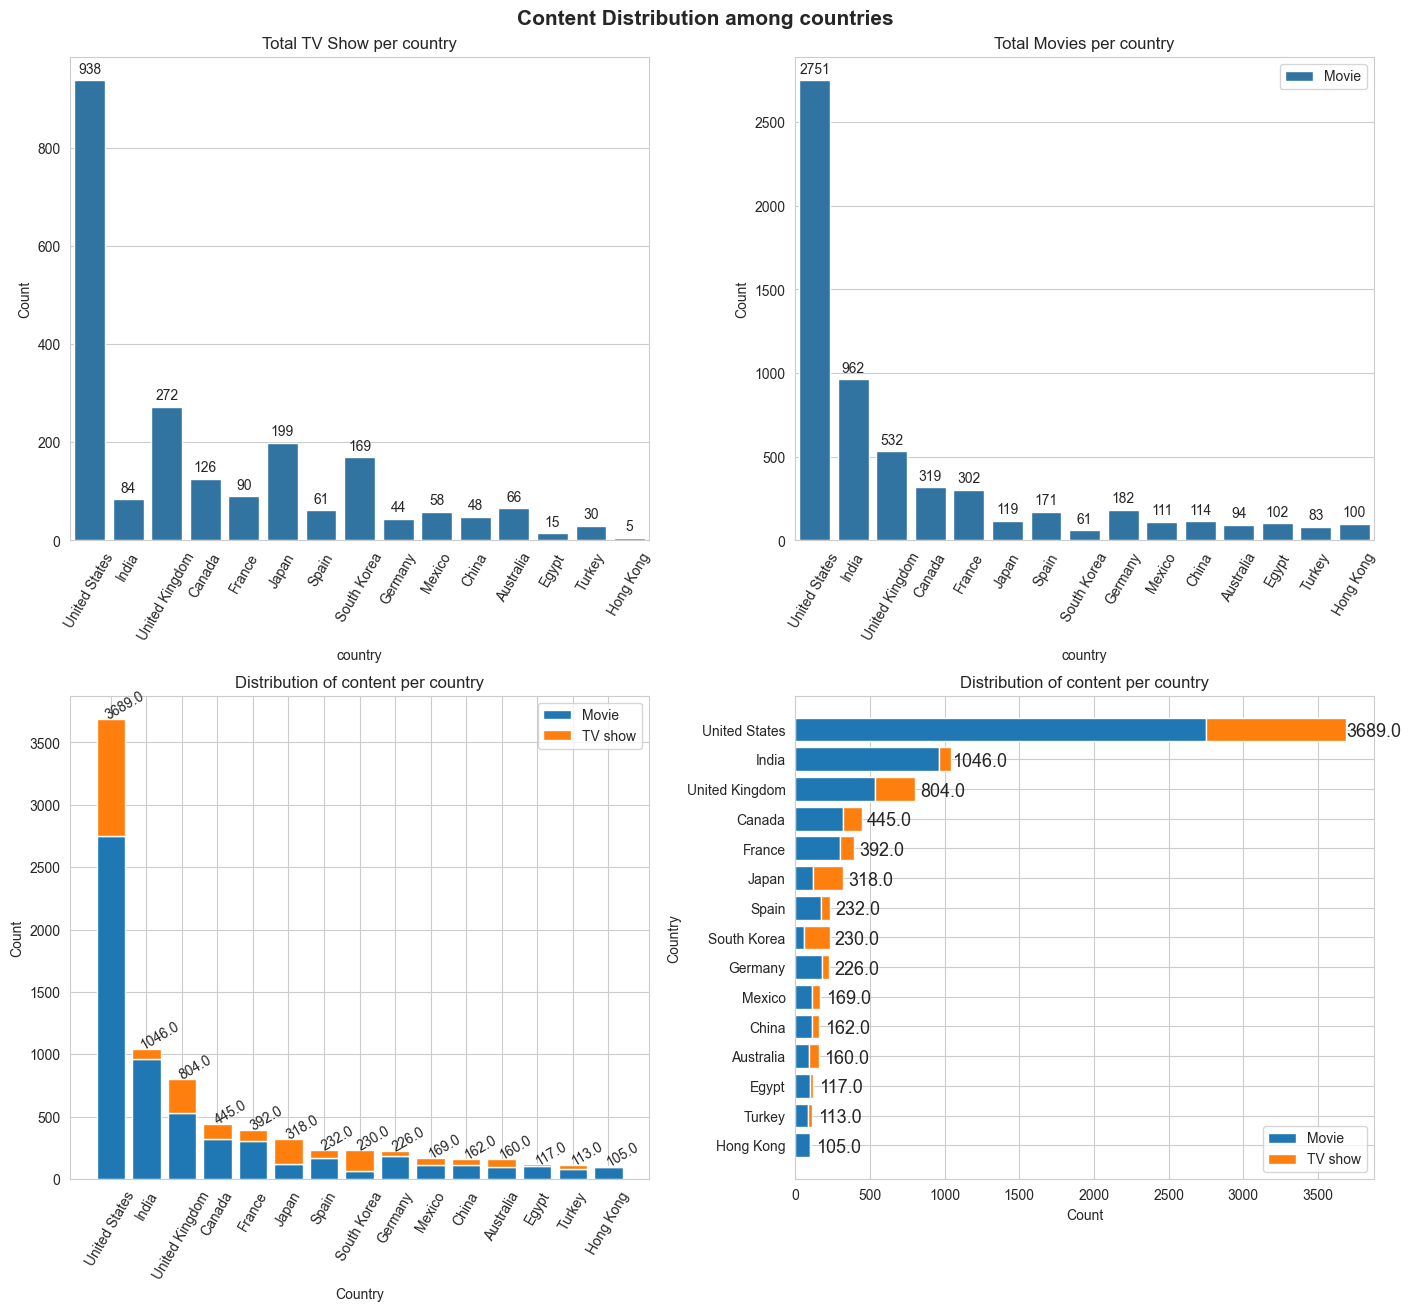

In [288]:
fig, ax = plt.subplots(ncols = 2, nrows= 2, figsize= (14,13), layout = "constrained")

sns.barplot(ax = ax[0, 0],data = da_countryTop15, x = da_countryTop15.index, y = da_countryTop15["TV Show"])
ax[0, 0].tick_params(axis = 'x', rotation = 60)
ax[0, 0].bar_label(ax[0, 0].containers[0], padding=3)
ax[0, 0].set_title("Total TV Show per country")
ax[0, 0].set_ylabel("Count")


sns.barplot(ax = ax[0, 1], data = da_countryTop15, x = da_countryTop15.index, y = da_countryTop15["Movie"], label = "Movie")
ax[0, 1].tick_params(axis = 'x', rotation = 60)
ax[0, 1].bar_label(ax[0,1].containers[0], padding=3)
ax[0, 1].set_title("Total Movies per country")
ax[0, 1].set_ylabel("Count")

ax[1, 0].bar(da_countryTop15.index, da_countryTop15["Movie"], label = "Movie")
ax[1, 0].bar(da_countryTop15.index, da_countryTop15["TV Show"], bottom=da_countryTop15["Movie"], label = "TV show")
ax[1, 0].legend()
ax[1, 0].tick_params(axis = 'x', rotation = 60)
ax[1, 0].set_xlabel("Country")
ax[1, 0].set_ylabel("Count")
# ax[1, 0].bar_label(ax[1, 0].containers[1], da_countryTop15["total"])
ax[1, 0].set(title = "Distribution of content per country")
for x, y in zip(da_countryTop15.index, da_countryTop15.total):
    ax[1, 0].annotate(str(y), (x, y), textcoords='offset points', xytext=(10, 0),
                     ha='center', fontsize=10, rotation = 30)

ax[1, 1].barh(y = da_countryTop15.index.values[::-1], width = da_countryTop15["Movie"][::-1], label = "Movie")
ax[1, 1].barh(y = da_countryTop15.index.values[::-1], width = da_countryTop15["TV Show"][::-1], left=da_countryTop15["Movie"][::-1], label = "TV show")
ax[1, 1].legend()
ax[1, 1].set_xlabel("Count")
ax[1, 1].set_ylabel("Country")
# plt.bar_label()
ax[1, 1].set(title = "Distribution of content per country")
for x, y in zip(da_countryTop15.index, da_countryTop15.total):
    ax[1, 1].annotate(str(y), (y, x), textcoords='offset points', xytext=(20, -5),
                     ha='center', fontsize=13)
fig.suptitle("Content Distribution among countries", fontsize=15, fontweight='bold')
# fig.tight_layout()
all_fig.append(fig)
plt.show()

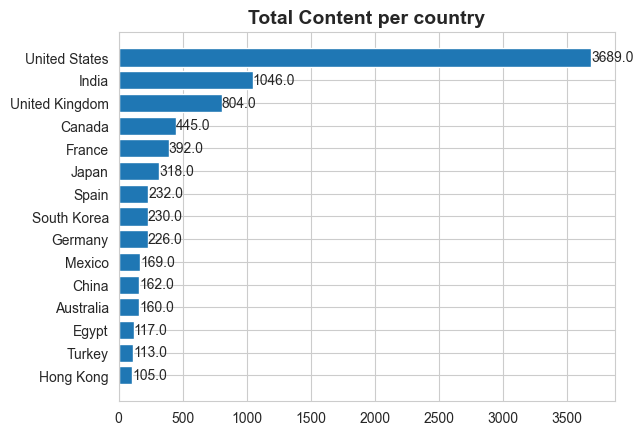

In [289]:
ax = plt.barh(y = da_countryTop15.index.values[::-1], width= da_countryTop15["total"][::-1])
plt.bar_label(ax, da_countryTop15["total"][::-1])
plt.title("Total Content per country", fontsize = 14, fontweight = 'bold')
all_fig.append(plt.gcf())
plt.show()

In [290]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_added,Rate_category
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,Teen
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,Adult
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,Adult
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,Adult
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,Adult
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019.0,Children
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,Adult
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,Teen


### Celebrity analysis

In [291]:
count_actor = df["cast"].str.split(", ").explode().value_counts().reset_index().head(10)
count_actor

,cast,count
0,Anupam Kher,43
1,Shah Rukh Khan,35
2,Julie Tejwani,33
3,Naseeruddin Shah,32
4,Takahiro Sakurai,32
5,Rupa Bhimani,31
6,Akshay Kumar,30
7,Om Puri,30
8,Yuki Kaji,29
9,Paresh Rawal,28


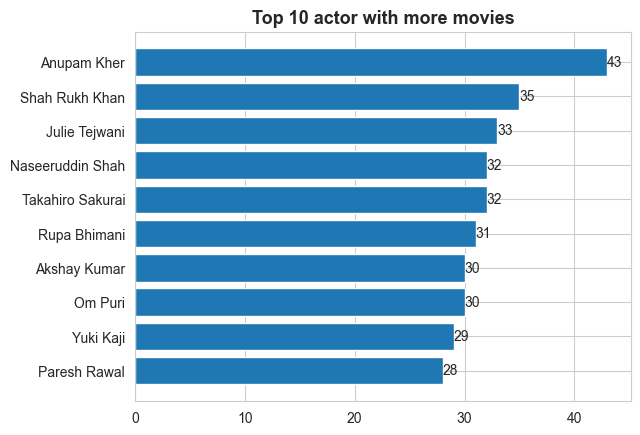

In [292]:
ax = plt.barh(y = count_actor["cast"][::-1], width= count_actor["count"][::-1])
plt.bar_label(ax, count_actor["count"][::-1])
plt.title("Top 10 actor with more movies", fontsize = 13, fontweight = "bold")
all_fig.append(plt.gcf())
plt.show()

In [293]:
# Taking first country as primary one and film and actor belongs to
country = df["country"].dropna().apply(lambda x : x.split(", ")[0]).reset_index()
country = country[country["country"] != ""]
country["country"]

0              United States
1               South Africa
2                      India
3              United States
4             United Kingdom
                ...         
7971    United Arab Emirates
7972           United States
7973           United States
7974           United States
7975                   India
Name: country, Length: 7974, dtype: object

In [294]:
actor = df["cast"].str.split(", ").explode().reset_index()
actor

,index,cast
0,0,NaN
1,1,Ama Qamata
2,1,Khosi Ngema
3,1,Gail Mabalane
4,1,Thabang Molaba
...,...,...
64946,8806,Manish Chaudhary
64947,8806,Meghna Malik
64948,8806,Malkeet Rauni
64949,8806,Anita Shabdish


In [295]:
country_actor = pd.merge(country, actor, how = "inner", left_on= country["index"], right_on= actor["index"]).drop(columns = ["index_x", "index_y"])
country_actor = country_actor.merge(df["type"], how = "inner",  left_on = "key_0", right_index= True).dropna()
country_actor

,key_0,country,cast,type
1,1,South Africa,Ama Qamata,TV Show
2,1,South Africa,Khosi Ngema,TV Show
3,1,South Africa,Gail Mabalane,TV Show
4,1,South Africa,Thabang Molaba,TV Show
5,1,South Africa,Dillon Windvogel,TV Show
...,...,...,...,...
59881,8806,India,Manish Chaudhary,Movie
59882,8806,India,Meghna Malik,Movie
59883,8806,India,Malkeet Rauni,Movie
59884,8806,India,Anita Shabdish,Movie


In [296]:
# # count_c_c =country_actor.groupby(["country"])["cast"].count()
# country_actor[["country", "cast"]].value_counts().reset_index().sort_values(by = ["country", "cast"], ascending= [True, True]).groupby(["country"], group_keys= False).apply(lambda x : x.nlargest(3, "count"))

In [297]:
# count_c_c =country_actor.groupby(["country", "cast"]).size().reset_index().rename(columns= {0 : "count"})
# count_c_c

### Total celebrities per country

In [298]:
cel_count = country_actor[["country", "cast"]].value_counts().reset_index().groupby(["country"])["cast"].count().reset_index().sort_values("cast", ascending= False).head(15)
cel_count

,country,cast
80,United States,13105
28,India,3710
78,United Kingdom,2896
10,Canada,1608
20,France,1344
35,Japan,1331
67,South Korea,1248
69,Spain,995
43,Mexico,892
12,China,693


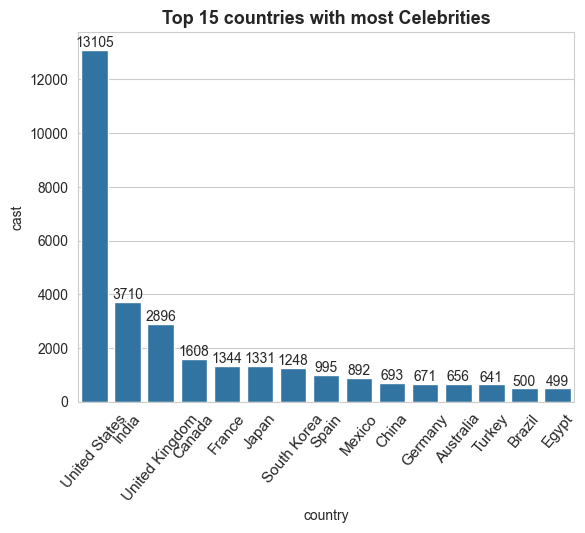

In [299]:
ax = sns.barplot(cel_count, x = "country", y = "cast")
plt.title("Top 15 countries with most Celebrities", fontsize = 13, fontweight = "bold")
plt.xticks(rotation = 50, fontsize = 11)
ax.bar_label(ax.containers[0])
all_fig.append(plt.gcf())
plt.show()

In [300]:
country_actor.groupby(["country"])["cast"].count()
# df.size()

country
Argentina          503
Australia          774
Austria             55
Bangladesh          21
Belarus              2
                 ...  
United States    23078
Uruguay             38
Venezuela            1
Vietnam             42
Zimbabwe            12
Name: cast, Length: 85, dtype: int64

C:\Users\DELL\AppData\Local\Temp\ipykernel_4848\3287513777.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



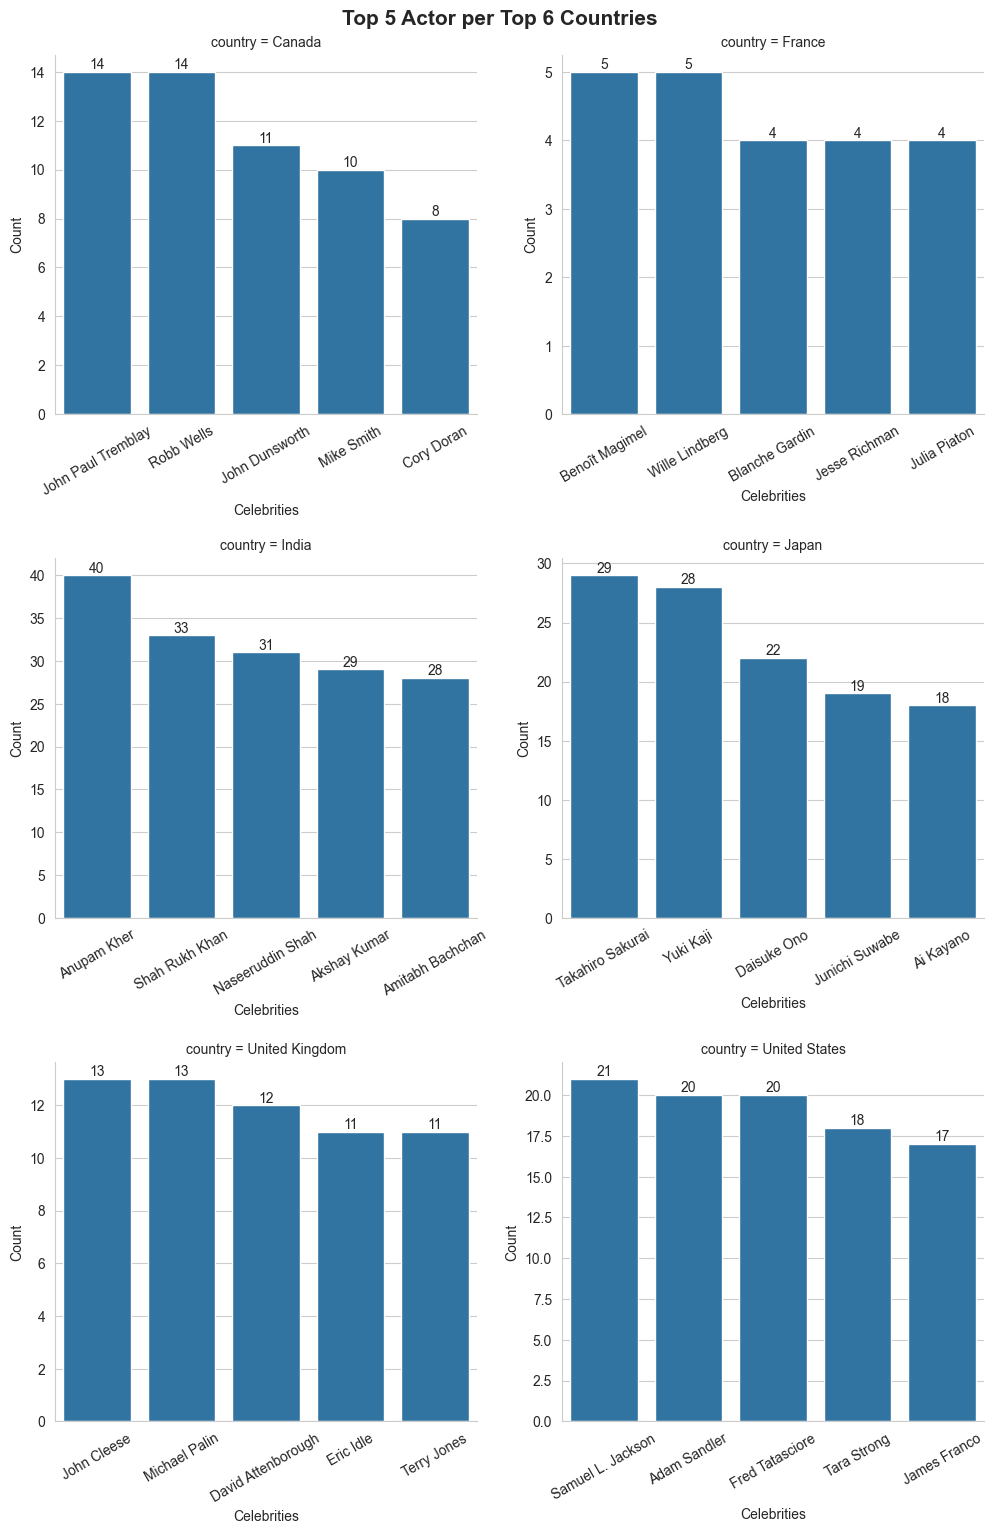

In [301]:
# Top 5 actor with most Movie and shows per Top 6 country with most content
count_c_c =country_actor.groupby(["country", "cast"]).size().reset_index().rename(columns= {0 : "count"})
top5_perCoun = count_c_c.groupby(["country"], group_keys= False).apply(lambda x : x.nlargest(5, "count"))
top5_perCoun

top_6_country = top5_perCoun[top5_perCoun["country"].isin(cel_count["country"].head(6))]
ax = sns.catplot(data = top_6_country, x = "cast", y = "count", col_wrap=2, col= "country", kind = "bar", sharex= False, sharey= False)
plt.suptitle("Top 5 Actor per Top 6 Countries", fontsize = 15, fontweight = "bold")
for i in ax.axes.flat:
    i.bar_label(i.containers[0])
    i.tick_params("x", rotation = 30)
    i.set( xlabel = "Celebrities", ylabel = "Count")

ax.fig.subplots_adjust(hspace=0.4, wspace=0.2, top = 0.95)
# fig.tight_layout()
all_fig.append(plt.gcf())

In [302]:
count_c_c =country_actor.groupby(["country", "cast", "type"]).size().reset_index().rename(columns= {0 : "count"})
top3_perCoun_pertype = count_c_c.groupby(["country", "type"], group_keys= False).apply(lambda x : x.nlargest(3, "count"))
top3_perCoun_pertype
top_6_country_pertype = top3_perCoun_pertype[top3_perCoun_pertype["country"].isin(cel_count["country"].head(6))]
top_6_country_pertype

C:\Users\DELL\AppData\Local\Temp\ipykernel_4848\2679225606.py:2: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,country,cast,type,count
2705,Canada,John Paul Tremblay,Movie,10
3319,Canada,Robb Wells,Movie,10
2701,Canada,John Dunsworth,Movie,8
2706,Canada,John Paul Tremblay,TV Show,4
3320,Canada,Robb Wells,TV Show,4
3326,Canada,Robert Tinkler,TV Show,4
7066,France,Wille Lindberg,Movie,5
5851,France,Benoît Magimel,Movie,4
5867,France,Blanche Gardin,Movie,4
5797,France,Antoine Gouy,TV Show,2


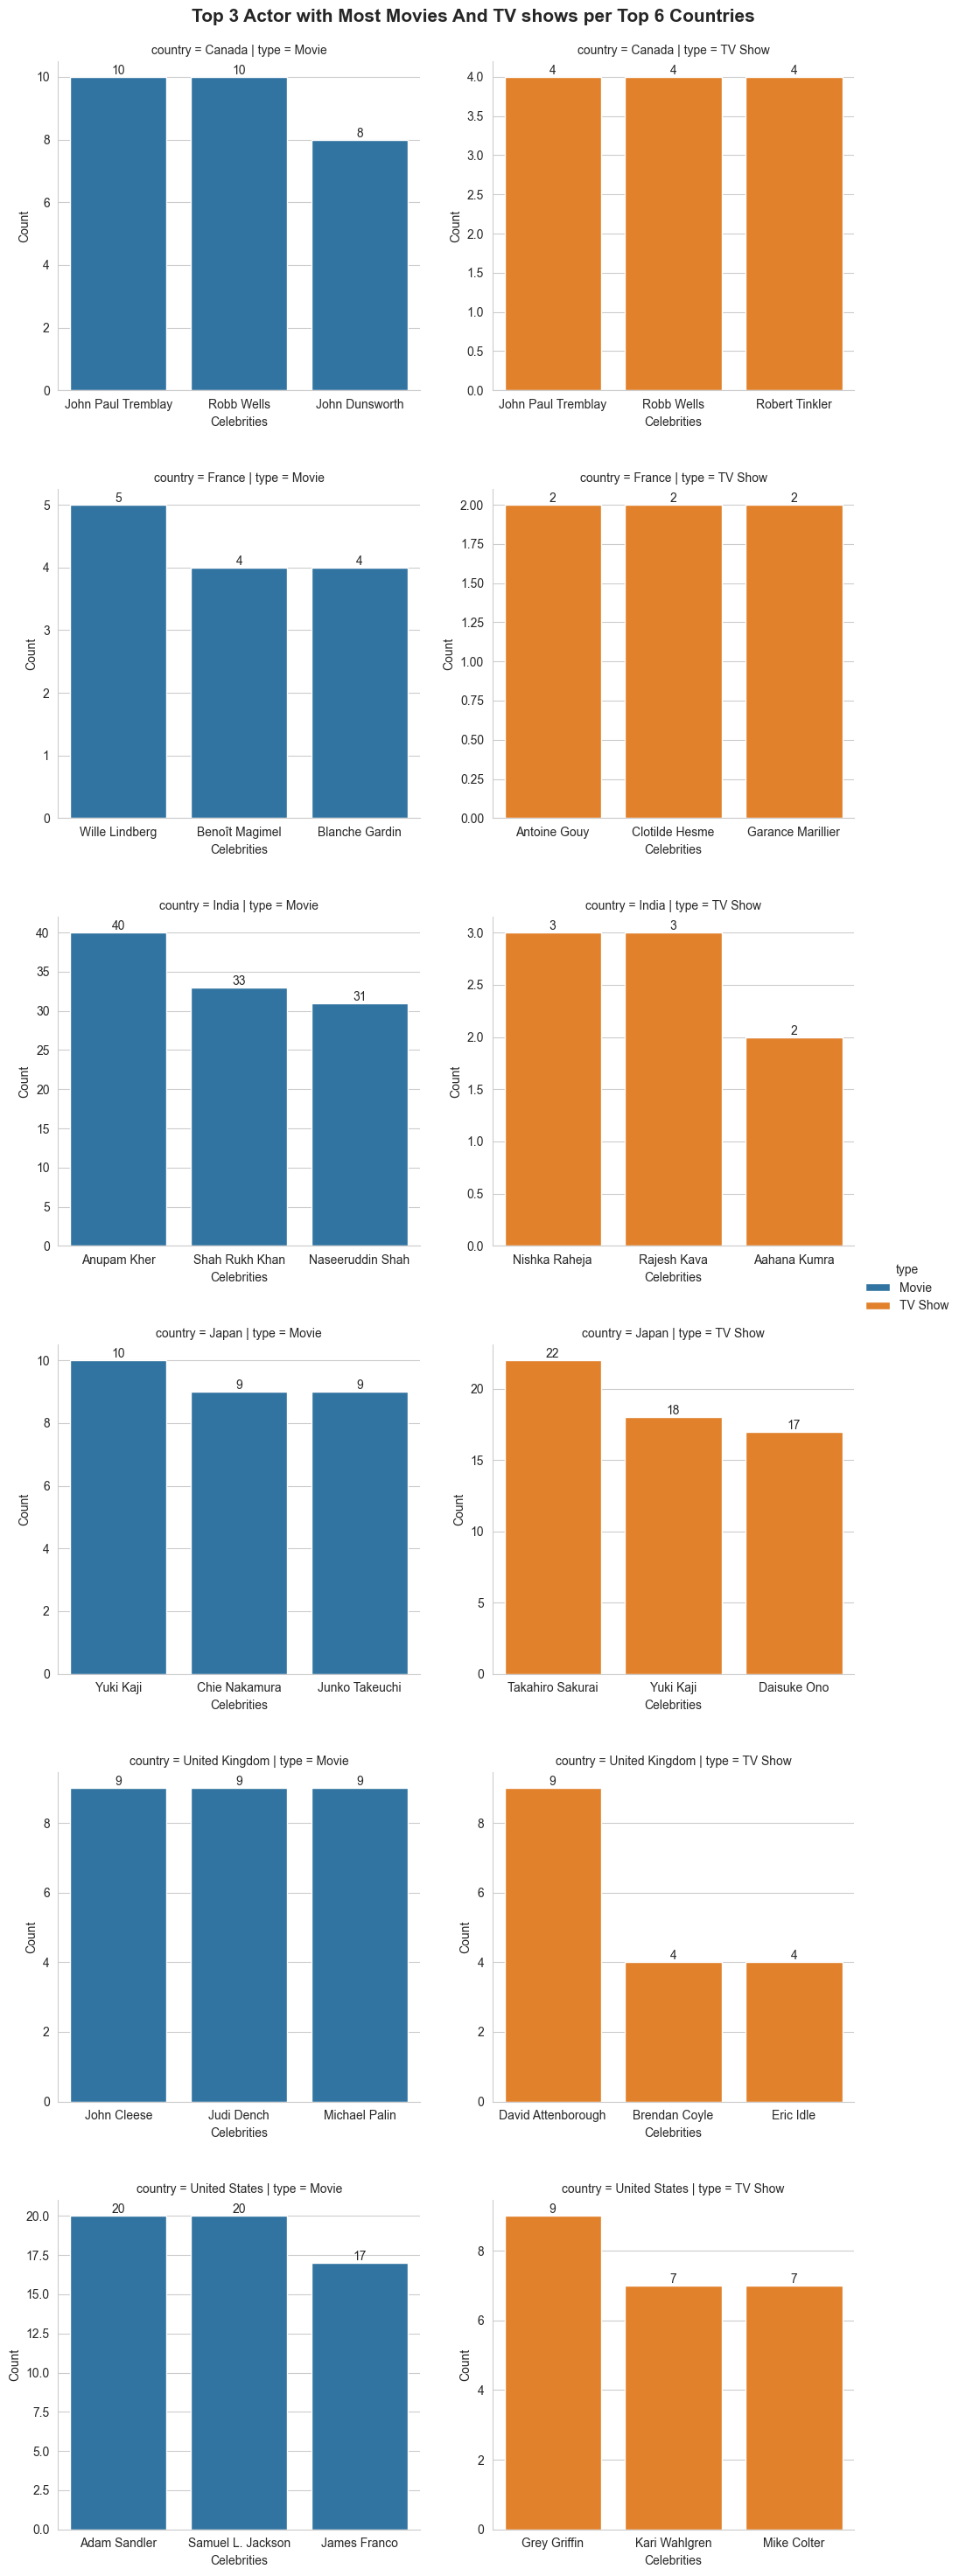

In [303]:
ax = sns.catplot(data = top_6_country_pertype, x = "cast", y = "count", row = "country", hue = "type", col= "type", kind = "bar", sharex= False, sharey= False)
# ax.set_titles"Top 3 Actor with Most Movies And TV shows per Top 6 Countries")
plt.suptitle("Top 3 Actor with Most Movies And TV shows per Top 6 Countries", fontsize = 15, fontweight = "bold")
ax.fig.subplots_adjust(hspace=0.3, wspace=0.2, top = 0.96)
for i in ax.axes.flat:
    i.bar_label(i.containers[0])
    i.bar_label(i.containers[1])
    i.set( xlabel = "Celebrities", ylabel = "Count")
all_fig.append(plt.gcf())
plt.show()

### Genre Analysis

In [304]:
li_count = df["listed_in"].str.split(", ").explode().value_counts().reset_index().head(20)
li_count

,listed_in,count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


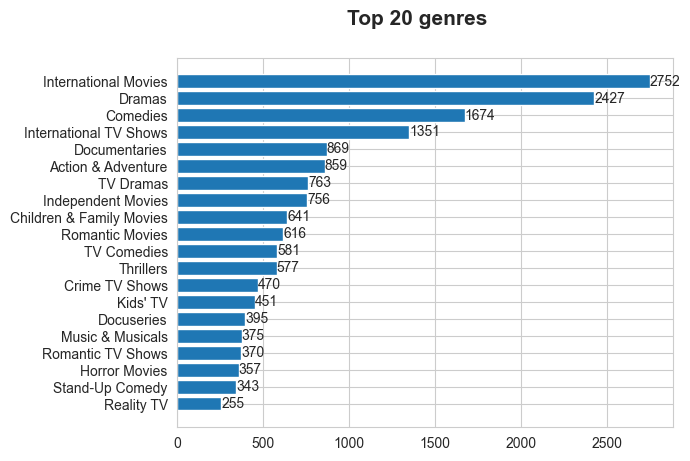

In [305]:
ax = plt.barh(y = li_count["listed_in"][::-1], width= li_count["count"][::-1])
plt.bar_label(ax, li_count["count"][::-1])
plt.suptitle("Top 20 genres", fontsize = 15, fontweight = "bold")
all_fig.append(plt.gcf())
plt.show()

### Content Duration Analysis

In [306]:
df["duration_int"] = df["duration"].str.extract(r'(\d+)').astype(float)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_added,Rate_category,duration_int
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,Teen,90.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,Adult,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,Adult,1.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,Adult,1.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,Adult,2.0


In [307]:
dur_movie = df[df["type"] == "Movie"]["duration_int"]
dur_movie


0        90.0
6        91.0
7       125.0
9       104.0
12      127.0
        ...  
8801     96.0
8802    158.0
8804     88.0
8805     88.0
8806    111.0
Name: duration_int, Length: 6131, dtype: float64

In [308]:
tv_show = df[df["type"] == "TV Show"]["duration_int"]
tv_show

1       2.0
2       1.0
3       1.0
4       2.0
5       1.0
       ... 
8795    2.0
8796    2.0
8797    3.0
8800    1.0
8803    2.0
Name: duration_int, Length: 2676, dtype: float64

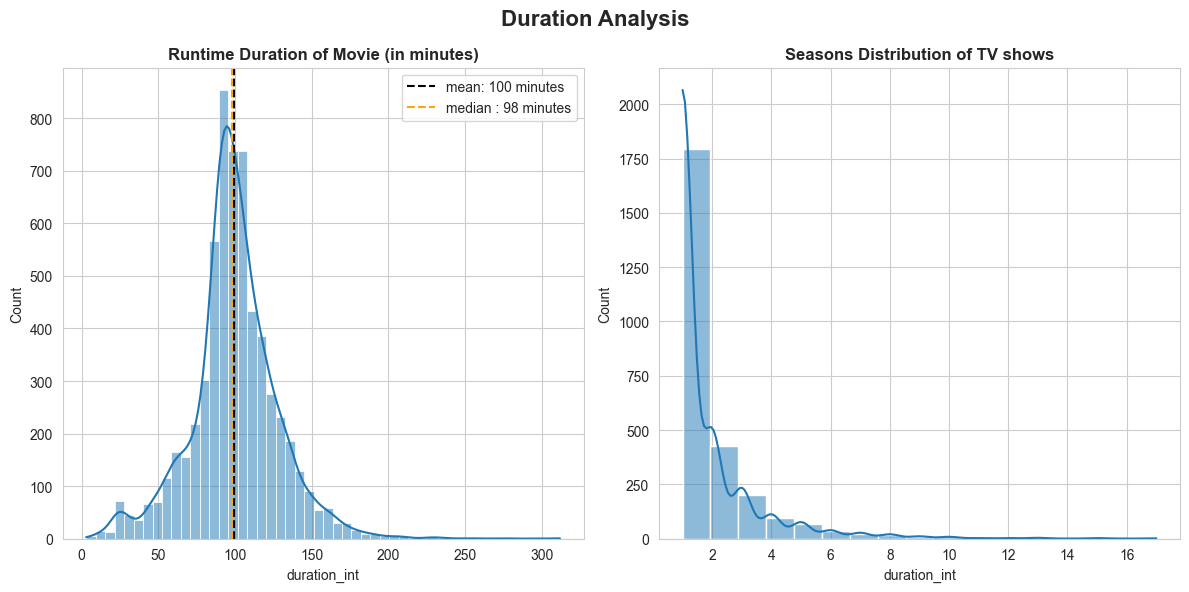

In [309]:
fig, ax = plt.subplots(ncols= 2, figsize = (12, 6))
sns.histplot(ax = ax[0], x = dur_movie, bins= 50, kde = True)
ax[0].axvline(dur_movie.mean(), color='black', linestyle='--',
                linewidth=1.5, label = f"mean: {dur_movie.mean():.0f} minutes")
ax[0].axvline(dur_movie.median(), color='orange', linestyle='--',
                linewidth=1.5, label = f"median : {dur_movie.median():.0f} minutes")
# plt.axvline(dur_movie.min(), label = "mean")
ax[0].legend()
ax[0].set_title("Runtime Duration of Movie (in minutes)", fontweight = "bold")
# ax.bar_label(ax.containers[0

# sns.kdeplot(x = dur_movie)

sns.histplot(ax = ax[1], x = tv_show, bins = 17, kde= True)
ax[1].set_title("Seasons Distribution of TV shows", fontweight = "bold")
# ax.bar_label(ax.containers[0])

fig.suptitle("Duration Analysis", fontweight = "bold", fontsize = 16)
fig.tight_layout()
all_fig.append(plt.gcf())
plt.show()


In [310]:
dur_movie_count = dur_movie.value_counts().reset_index().sort_values(by = "duration_int")
dur_movie_count

,duration_int,count
187,3.0,1
199,5.0,1
201,8.0,1
174,9.0,1
188,10.0,1
...,...,...
193,233.0,1
194,237.0,1
196,253.0,1
175,273.0,1


In [311]:
tv_show_count = tv_show.dropna().value_counts().reset_index()
tv_show_count

,duration_int,count
0,1.0,1793
1,2.0,425
2,3.0,199
3,4.0,95
4,5.0,65
5,6.0,33
6,7.0,23
7,8.0,17
8,9.0,9
9,10.0,7


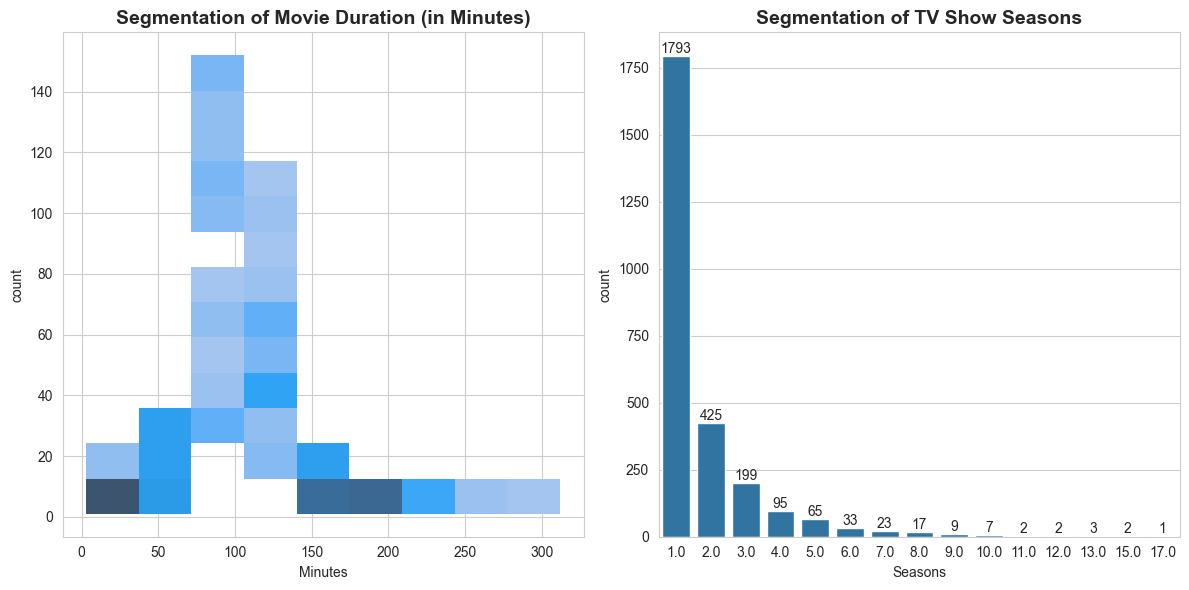

In [312]:
fig, ax = plt.subplots(ncols= 2, figsize = (12, 6))
sns.histplot(ax = ax[0], x = dur_movie_count["duration_int"], y = dur_movie_count["count"])
ax[0].set_title("Segmentation of Movie Duration (in Minutes)", fontsize = 14, fontweight = "bold")
# ax.bar_label(ax.containers[0])
# ax.bar_label(ax.containers[0])
ax[0].set(xlabel = "Minutes")
# plt.show()

sns.barplot(ax = ax[1], x = tv_show_count["duration_int"], y = tv_show_count["count"])
ax[1].bar_label(ax[1].containers[0])
ax[1].set(xlabel = "Seasons")
ax[1].set_title("Segmentation of TV Show Seasons", fontsize = 14, fontweight = "bold")
fig.tight_layout()
all_fig.append(fig)
plt.show()

## Word cloud - Movie and tv shows

In [202]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
print("Done")

Done


In [203]:
def clean_token(token):
    return [t for t in token if t not in stop_word]

def word_cloud(data):
    stop_word = stopwords.words("english")
    token = des_Movie.str.translate(str.maketrans('', '', string.punctuation))
    token = token.apply(lambda x : nltk.word_tokenize(x))
    
    cleaned_data = token.apply(lambda x : [t for t in x if t not in stop_word])
    # cleaned_data
    
    str_movie = ""
    for i in cleaned_data:
        for j in i:
            str_movie += j + " "
    word_cloud = WordCloud(width = 900, height= 600, background_color="white").generate(str_movie)
    return word_cloud

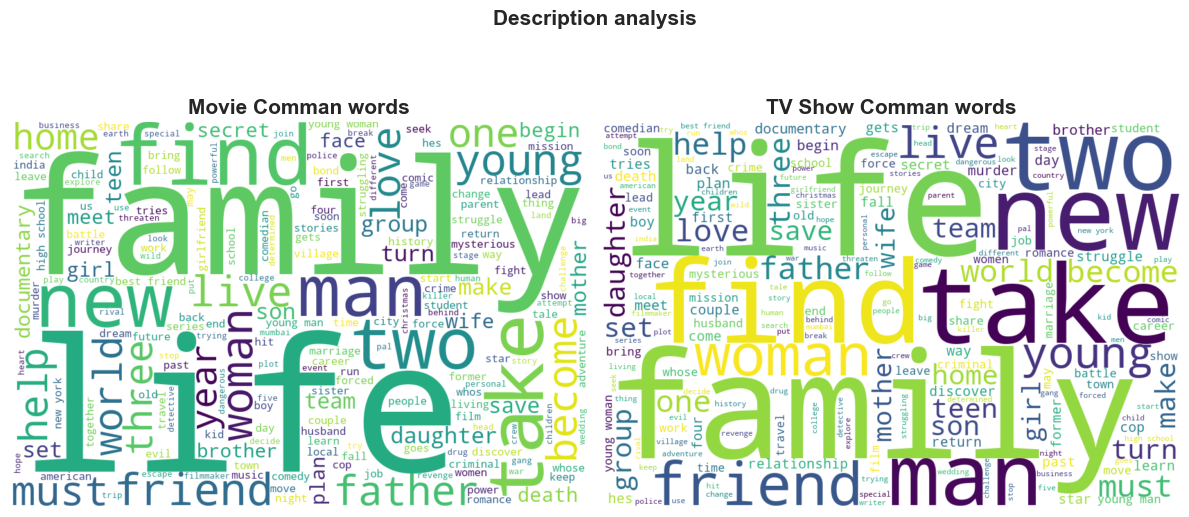

In [313]:
fig, ax = plt.subplots(ncols= 2, figsize = (12, 6))

des_Movie = df[df["type"] == "Movie"]["description"].str.lower()
des_Movie
ax[0].imshow(word_cloud(des_Movie), interpolation='bilinear')
ax[0].axis("off")
ax[0].set_title("Movie Comman words", fontsize = 15, fontweight = "bold")

des_TV_show = df[df["type"] == "TV Show"]["description"].str.lower()
des_TV_show
ax[1].imshow(word_cloud(des_TV_show), interpolation='bilinear')
ax[1].axis("off")
ax[1].set_title("TV Show Comman words", fontsize = 15, fontweight = "bold")

fig.suptitle("Description analysis", fontsize = 15, fontweight = "bold")
fig.tight_layout()
all_fig.append(fig)
plt.show()

In [89]:
def polority_check(data):
    sent = SentimentIntensityAnalyzer()

    scores = sent.polarity_scores(data)

    compound = scores["compound"]

    if compound >= 0.05:
        return "postive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

In [90]:
stop_word = stopwords.words("english")
token = des_Movie.str.translate(str.maketrans('', '', string.punctuation))
token = token.apply(lambda x : nltk.word_tokenize(x))
    
cleaned_data = token.apply(lambda x : [t for t in x if t not in stop_word])
cleaned_data = cleaned_data.apply(lambda x: " ".join(x))
cleaned_data
# movie
movie_senti = cleaned_data.apply(polority_check)
movie_senti

0       negative
6        postive
7       negative
9       negative
12      negative
          ...   
8801     neutral
8802    negative
8804    negative
8805    negative
8806    negative
Name: description, Length: 6131, dtype: object

In [91]:
stop_word = stopwords.words("english")
token = des_TV_show.str.translate(str.maketrans('', '', string.punctuation))
token = token.apply(lambda x : nltk.word_tokenize(x))
    
cleaned_data = token.apply(lambda x : [t for t in x if t not in stop_word])
cleaned_data = cleaned_data.apply(lambda x: " ".join(x))
cleaned_data
Tv_show_senti = cleaned_data.apply(polority_check)
Tv_show_senti

1       negative
2       negative
3        postive
4        postive
5        postive
          ...   
8795     postive
8796     neutral
8797     neutral
8800     postive
8803    negative
Name: description, Length: 2676, dtype: object

In [92]:
movie = movie_senti.value_counts().reset_index()
movie

,description,count
0,negative,2784
1,postive,2671
2,neutral,676


In [93]:
tv_senti = Tv_show_senti.value_counts().reset_index()
tv_senti

,description,count
0,postive,1381
1,negative,983
2,neutral,312


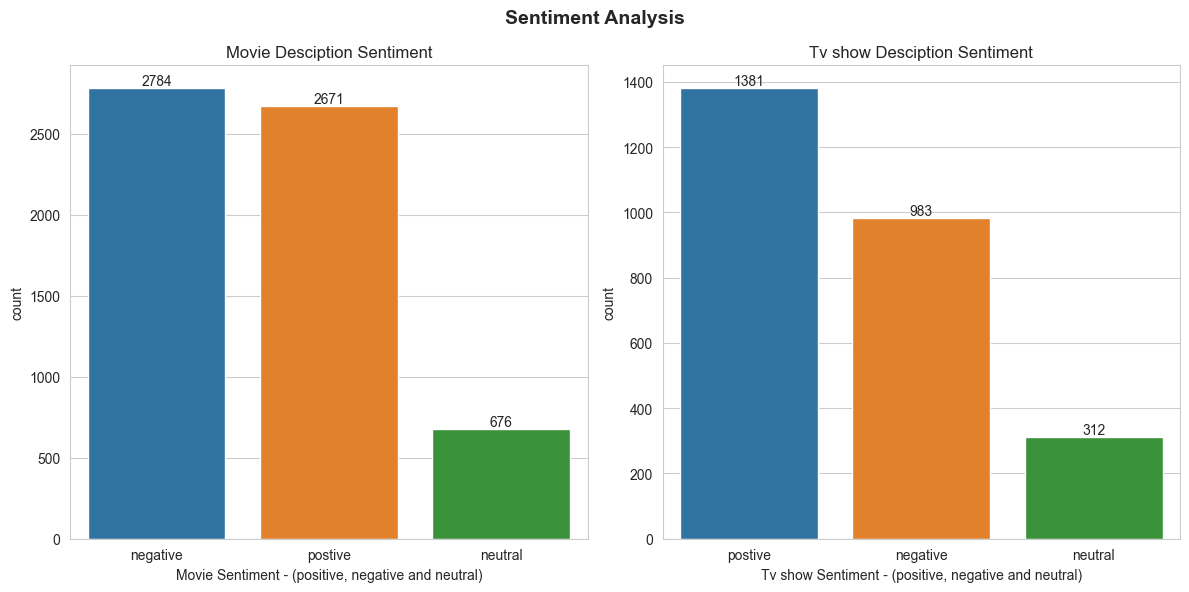

In [348]:
fig, ax = plt.subplots(ncols= 2, figsize = (12, 6))

sns.barplot(ax = ax[0], x= movie["description"], y = movie["count"], hue  =  movie["description"])
ax[0].set_title("Movie Desciption Sentiment")
ax[0].set_xlabel("Movie Sentiment - (positive, negative and neutral)")
ax[0].bar_label(ax[0].containers[0])
ax[0].bar_label(ax[0].containers[1])
ax[0].bar_label(ax[0].containers[2])

sns.barplot(ax = ax[1], x = tv_senti["description"], y = tv_senti["count"], hue  =  tv_senti["description"])
ax[1].set_title("Tv show Desciption Sentiment")
ax[1].set_xlabel("Tv show Sentiment - (positive, negative and neutral)")
ax[1].bar_label(ax[1].containers[0])
ax[1].bar_label(ax[1].containers[1])
ax[1].bar_label(ax[1].containers[2])

fig.suptitle("Sentiment Analysis", fontsize = 14, fontweight = "bold")
fig.tight_layout()
all_fig.append(fig)
plt.show()

In [326]:
# for Getting image
from IPython.display import display
def get_image(all_fig):
    for i in enumerate(all_fig):
        fig.savefig(f"Untitled Folder 1/figure_{i}.png", dpi=100, bbox_inches='tight')
        display(fig)
get_image(all_fig)

In [327]:
# for Getting pdf
from matplotlib.backends.backend_pdf import PdfPages
def get_pdf(all_fig):
    with PdfPages("NetflixChart.pdf") as pdf:
        for fig in all_fig:
            pdf.savefig(fig, bbox_inches= "tight")
get_pdf(all_fig)